In [1]:
!pip install mlxtend

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules



In [3]:
df = pd.read_csv(r"C:\Users\AB\Downloads\archive (24)\OnlineRetail.csv", encoding='ISO-8859-1')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [6]:
df = df.dropna(subset=['Description'])

In [7]:
basket = (df
          .groupby(['InvoiceNo','Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

In [16]:
print(pd.__version__)
print(type(basket))
print(hasattr(basket, 'applymap'))

3.0.5
<class 'pandas.DataFrame'>
False


In [17]:
basket = (basket > 0).astype(int)

basket.iloc[:, :10].head()


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET
InvoiceNo,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0


In [18]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

c:\Users\AB\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.039066,frozenset({6 RIBBONS RUSTIC CHARM})
1,0.025280,frozenset({60 CAKE CASES VINTAGE CHRISTMAS})
2,0.033871,frozenset({60 TEATIME FAIRY CAKE CASES})
3,0.025157,frozenset({72 SWEETHEART FAIRY CAKE CASES})
4,0.040088,frozenset({ALARM CLOCK BAKELIKE GREEN})


In [19]:
frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

frequent_itemsets.head(20)

,support,itemsets
181,0.092449,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
72,0.085576,frozenset({JUMBO BAG RED RETROSPOT})
141,0.081363,frozenset({REGENCY CAKESTAND 3 TIER})
114,0.068968,frozenset({PARTY BUNTING})
93,0.063978,frozenset({LUNCH BAG RED RETROSPOT})
9,0.059519,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
153,0.056655,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
108,0.053997,frozenset({PACK OF 72 RETROSPOT CAKE CASES})
86,0.052074,frozenset({LUNCH BAG BLACK SKULL.})
101,0.051092,frozenset({NATURAL SLATE HEART CHALKBOARD })


In [20]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({JUMBO BAG PINK POLKADOT}),frozenset({JUMBO BAG RED RETROSPOT}),0.049824,0.085576,0.033748,0.677340,7.915034,1.0,0.029484,2.834015,0.919470,0.331992,0.647144,0.535850
1,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.041520,0.043606,0.031416,0.756650,17.351850,1.0,0.029606,3.930120,0.983191,0.584920,0.745555,0.738550
2,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.043606,0.041520,0.031416,0.720450,17.351850,1.0,0.029606,3.428656,0.985336,0.584920,0.708341,0.738550
3,frozenset({JUMBO STORAGE BAG SUKI}),frozenset({JUMBO BAG RED RETROSPOT}),0.048433,0.085576,0.029616,0.611486,7.145506,1.0,0.025472,2.353647,0.903827,0.283699,0.575127,0.478783
4,frozenset({JUMBO SHOPPER VINTAGE RED PAISLEY}),frozenset({JUMBO BAG RED RETROSPOT}),0.048065,0.085576,0.027816,0.578723,6.762654,1.0,0.023703,2.170602,0.895155,0.262853,0.539298,0.451886


In [21]:
rules = rules.sort_values(
    by='lift',
    ascending=False
)

rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head(20)

,antecedents,consequents,support,confidence,lift
21,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.022171,0.705729,22.522526
22,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.022171,0.707572,22.522526
23,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.022171,0.533990,21.792860
20,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.022171,0.904841,21.792860
9,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.025894,0.623645,19.902916
8,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.025894,0.826371,19.902916
24,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.022171,0.508443,19.635691
19,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.022171,0.856240,19.635691
17,frozenset({GARDENERS KNEELING PAD KEEP CALM }),frozenset({GARDENERS KNEELING PAD CUP OF TEA }),0.022335,0.598028,19.286813
18,frozenset({GARDENERS KNEELING PAD CUP OF TEA }),frozenset({GARDENERS KNEELING PAD KEEP CALM }),0.022335,0.720317,19.286813


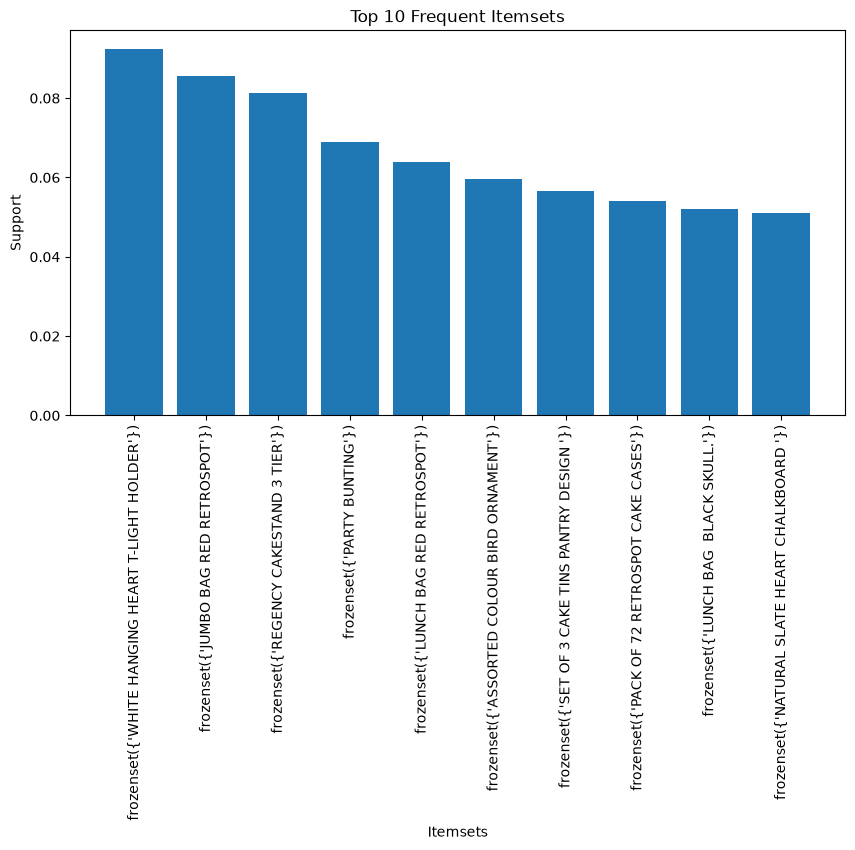

In [22]:
top_items = frequent_itemsets.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_items['itemsets'].astype(str),
    top_items['support']
)

plt.xticks(rotation=90)
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Top 10 Frequent Itemsets")

plt.show()

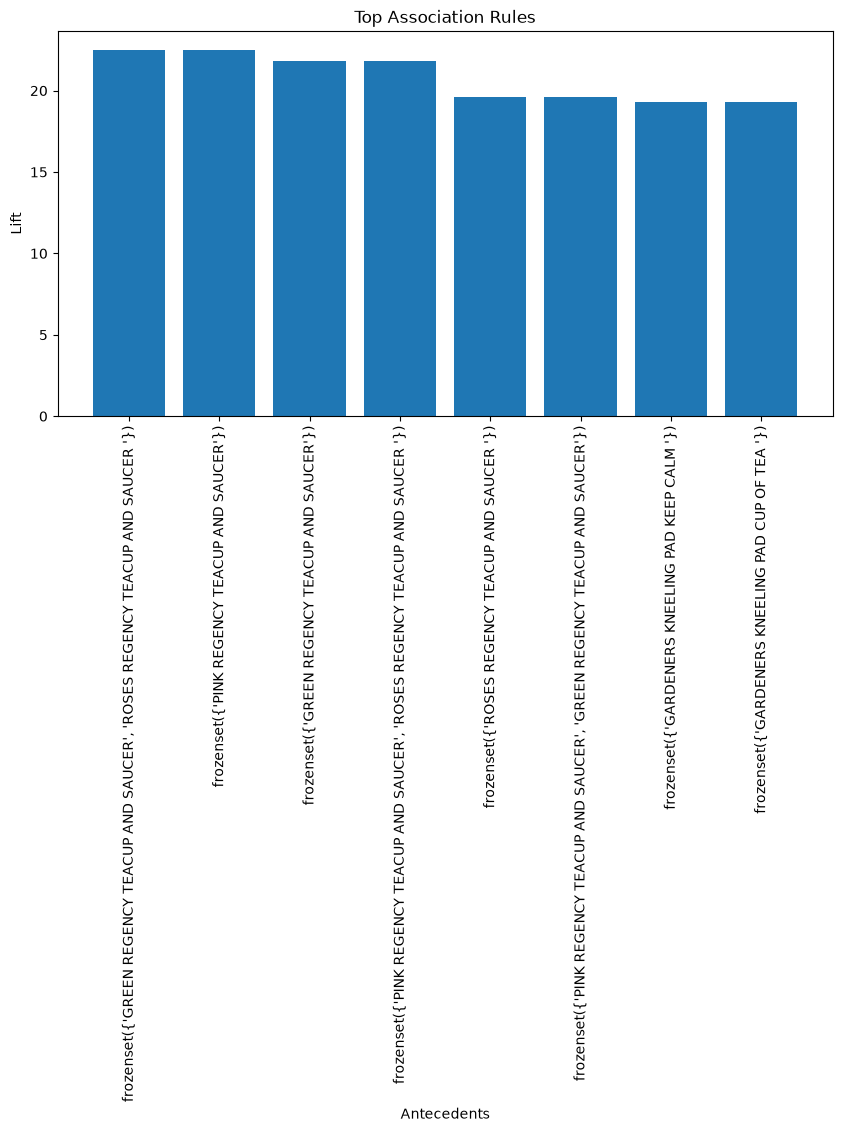

In [23]:
top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_rules['antecedents'].astype(str),
    top_rules['lift']
)

plt.xticks(rotation=90)
plt.xlabel("Antecedents")
plt.ylabel("Lift")
plt.title("Top Association Rules")

plt.show()

In [24]:
print("\nBusiness Insights")

for i, row in rules.head(10).iterrows():
    print("-----------------------------------")
    print("If customer buys:", list(row['antecedents']))
    print("Recommend:", list(row['consequents']))
    print("Confidence:", round(row['confidence'],2))
    print("Lift:", round(row['lift'],2))


Business Insights
-----------------------------------
If customer buys: ['GREEN REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ']
Recommend: ['PINK REGENCY TEACUP AND SAUCER']
Confidence: 0.71
Lift: 22.52
-----------------------------------
If customer buys: ['PINK REGENCY TEACUP AND SAUCER']
Recommend: ['GREEN REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ']
Confidence: 0.71
Lift: 22.52
-----------------------------------
If customer buys: ['GREEN REGENCY TEACUP AND SAUCER']
Recommend: ['PINK REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ']
Confidence: 0.53
Lift: 21.79
-----------------------------------
If customer buys: ['PINK REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ']
Recommend: ['GREEN REGENCY TEACUP AND SAUCER']
Confidence: 0.9
Lift: 21.79
-----------------------------------
If customer buys: ['GREEN REGENCY TEACUP AND SAUCER']
Recommend: ['PINK REGENCY TEACUP AND SAUCER']
Confidence: 0.62
Lift: 19.9
--------------